In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import pytensor
import pytensor.tensor as pt
from pytensor.graph.fg import FunctionGraph
from pytensor.graph.features import History, FullHistory
from pytensor.graph.rewriting.utils import rewrite_graph

In [4]:
 x = pt.scalar("x")
out = pt.log(pt.exp(x) / pt.sum(pt.exp(x)))

fg = FunctionGraph(outputs=[out])
history = FullHistory()
fg.attach_feature(history)

rewrite_graph(fg, clone=False, include=("canonicalize", "stabilize"))

FunctionGraph(LogSoftmax{axis=None}(x))

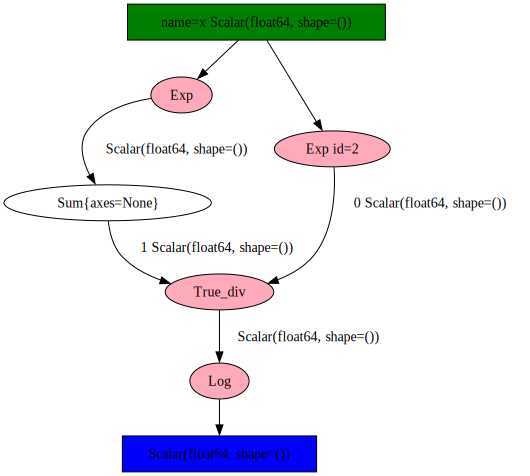

In [5]:
import graphviz
from pytensor.printing import pydotprint
out = pydotprint(history.start(), str)
gv = graphviz.Source(out.to_string())
gv

In [6]:
import pathlib
import os
(pathlib.Path().parent / "widget.js").absolute()

PosixPath('/home/evelin/Documents/Ricardo/Projects/pytensor/notebooks/widget.js')

In [1]:
import anywidget
import traitlets

class CounterWidget(anywidget.AnyWidget):
    # Widget front-end JavaScript code
    _esm = """
    function render({ model, el }) {
      let button = document.createElement("button");
      button.innerHTML = `count is ${model.get("value")}`;
      button.addEventListener("click", () => {
        model.set("value", model.get("value") + 1);
        model.save_changes();
      });
      model.on("change:value", () => {
        button.innerHTML = `count is ${model.get("value")}`;
      });
      el.appendChild(button);
    }
    export default { render };
    """
    # Stateful property that can be accessed by JavaScript & Python
    value = traitlets.Int(0).tag(sync=True)
    
counter = CounterWidget()
counter

CounterWidget()

In [4]:
import ipywidgets
ipywidgets.IntSlider(max=5, value=0)

IntSlider(value=0, max=5)

In [18]:
import anywidget
import pathlib
import traitlets
import ipywidgets

class GraphvizWidget(anywidget.AnyWidget):
    """
    Graphviz widget to render multiple graphviz graphs.

    The index will choose the one that is currently displayed, defaulting to the last one.
    If the index or the graphs change, there will be a re-rendering, with animation.
    """

    _esm = r"/home/evelin/Documents/Ricardo/Projects/pytensor/notebooks/widget.js"
    _css = r"/home/evelin/Documents/Ricardo/Projects/pytensor/notebooks/widget.css"
    dots = traitlets.List().tag(sync=True)
    index = traitlets.Int(0, allow_none=True).tag(sync=True)
    performance = traitlets.Bool(False).tag(sync=True)

    
class CounterWidget(anywidget.AnyWidget):
    # Widget front-end JavaScript code
    _esm = """
    function render({ model, el }) {
      let button = document.createElement("button");
      button.innerHTML = `count is ${model.get("value")}`;
      button.addEventListener("click", () => {
        model.set("value", model.get("value") + 1);
        model.save_changes();
      });
      model.on("change:value", () => {
        button.innerHTML = `count is ${model.get("value")}`;
      });
      el.appendChild(button);
    }
    export default { render };
    """
    # Stateful property that can be accessed by JavaScript & Python
    value = traitlets.Int(0).tag(sync=True)
    

def graphviz_widget_with_slider(dots: list[str], *, performance: bool = False) -> ipywidgets.VBox:
    n_dots = len(dots)
    graphviz_widget = GraphvizWidget()
    graphviz_widget.dots = dots
    graphviz_widget.performance = performance
    slider_widget = ipywidgets.IntSlider(max=n_dots - 1, value=0)
    ipywidgets.jslink((slider_widget, "value"), (graphviz_widget, "index"))
#     play_widget = ipywidgets.Play(max=n_dots - 1, repeat=True, interval=4000)
#     ipywidgets.jslink((slider_widget, "value"), (play_widget, "value"))
#     top = ipywidgets.HBox([play_widget, slider_widget])
    return ipywidgets.VBox([slider_widget, CounterWidget()])

In [19]:
graphviz_widget_with_slider([out.to_string(), out.to_string()])

In [25]:
import graphviz
from pytensor.printing import pydotprint
out = pydotprint(predict, str)
gv = graphviz.Source(out.to_string())

In [ ]:
from IPython.display import Image
Image('./examples/mlp.png', width='80%')

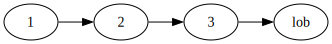

In [11]:
import graphviz
src = graphviz.Source('digraph "the holy hand grenade" { rankdir=LR; 1 -> 2 -> 3 -> lob }')
src

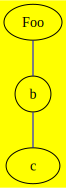

In [3]:
import pydot
import graphviz

dot_string = """graph my_graph {
    bgcolor="yellow";
    a [label="Foo"];
    b [shape=circle];
    a -- b -- c [color=blue];
}"""

graphviz.Source(dot_string)

In [ ]:
import io
file = io.StringIO()
file.endswith = lambda *args: True
pydotprint(predict, file)

In [ ]:
??pydotprint